# Progetto 2 del Modulo 3
Machine Learning - Dataset Linnerud

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_linnerud
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

1. Data Exploration & Preprocessing

In [4]:
#Caricamento e analisoi del dataset
linnerud = load_linnerud()
X = pd.DataFrame(linnerud.data, columns=linnerud.feature_names)
y = pd.DataFrame(linnerud.target, columns=linnerud.target_names)

print("--- Analisi Descrittiva delle Feature (X) ---")
print(X.describe())

print("\n--- Analisi Descrittiva dei Target (y) ---")
print(y.describe())

--- Analisi Descrittiva delle Feature (X) ---
           Chins      Situps      Jumps
count  20.000000   20.000000   20.00000
mean    9.450000  145.550000   70.30000
std     5.286278   62.566575   51.27747
min     1.000000   50.000000   25.00000
25%     4.750000  101.000000   39.50000
50%    11.500000  122.500000   54.00000
75%    13.250000  210.000000   85.25000
max    17.000000  251.000000  250.00000

--- Analisi Descrittiva dei Target (y) ---
           Weight      Waist      Pulse
count   20.000000  20.000000  20.000000
mean   178.600000  35.400000  56.100000
std     24.690505   3.201973   7.210373
min    138.000000  31.000000  46.000000
25%    160.750000  33.000000  51.500000
50%    176.000000  35.000000  55.000000
75%    191.500000  37.000000  60.500000
max    247.000000  46.000000  74.000000


In [5]:
#Standardizzazione delle feature
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

df_X_scaled = pd.DataFrame(X_scaled, columns=linnerud.feature_names)
print("Feature Standardizzate (prime 5 righe)")
print(df_X_scaled.head())

Feature Standardizzate (prime 5 righe)
      Chins    Situps     Jumps
0 -0.863671  0.269750 -0.206086
1 -1.445921 -0.582956 -0.206086
2  0.494912 -0.730539  0.614257
3  0.494912 -0.664946 -0.666279
4  0.688996  0.154963 -0.246103


2. Target Engineering

In [10]:
#Standardizzazione della matrice dei target
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y)
df_y_sclaed = pd.DataFrame(y_scaled, columns=linnerud.target_names)

#Scenario A
#Applicazione PCA alla matrice dei target standardizzata tenendo PC1
pca_y = PCA(n_components=1)
y_pca = pca_y.fit_transform(y_scaled).flatten()

#Scenario B
#Selezione 'Waist' come singolo target
y_manual = df_y_sclaed['Waist'].values

3. Addestramento & Valutazione

In [11]:
# Inizializzazione dei modelli
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0),
    'Lasso (alpha=0.1)': Lasso(alpha=0.1)
}

# Dizionari per salvare i risultati
results = []

# Scenari da ciclare
scenarios = {
    'PCA (Target Composto)': y_pca,
    'Manuale (Waist)': y_manual
}

# Loop di addestramento e valutazione
for target_name, y_target in scenarios.items():
    for model_name, model in models.items():
        # Addestramento
        model.fit(X_scaled, y_target)
        
        # Predizione
        y_pred = model.predict(X_scaled)
        
        # Metriche
        mse = mean_squared_error(y_target, y_pred)
        r2 = r2_score(y_target, y_pred)
        
        # Salvataggio risultati
        results.append({
            'Scenario': target_name,
            'Modello': model_name,
            'MSE': mse,
            'R2 Score': r2
        })

# Mostriamo i risultati in una tabella leggibile
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

             Scenario           Modello      MSE  R2 Score
PCA (Target Composto) Linear Regression 1.268880  0.396958
PCA (Target Composto) Ridge (alpha=1.0) 1.275908  0.393618
PCA (Target Composto) Lasso (alpha=0.1) 1.332376  0.366781
      Manuale (Waist) Linear Regression 0.452156  0.547844
      Manuale (Waist) Ridge (alpha=1.0) 0.456687  0.543313
      Manuale (Waist) Lasso (alpha=0.1) 0.515654  0.484346


4. Analisi & Valutazione

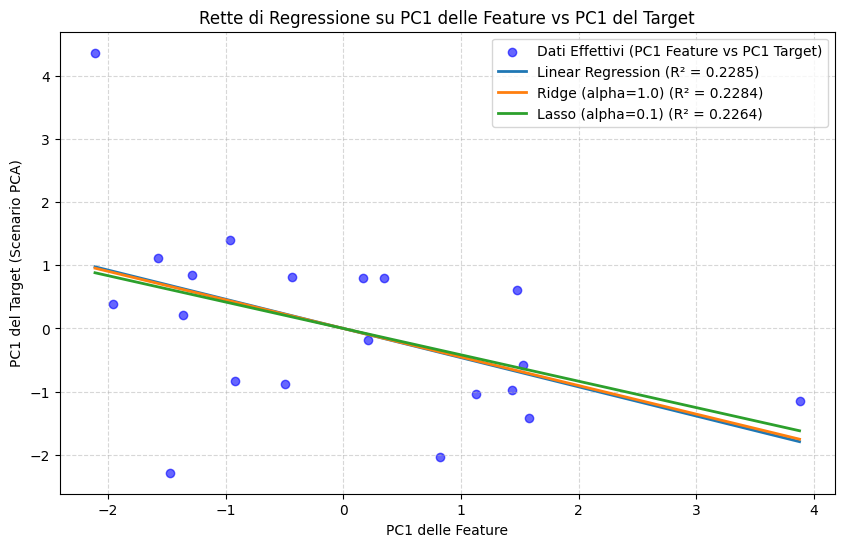

In [12]:
# PCA sulle Feature
pca_X = PCA(n_components=2)
X_pca = pca_X.fit_transform(X_scaled)
X_pc1 = X_pca[:, 0].reshape(-1, 1) # Prendiamo solo PC1 


plt.figure(figsize=(10, 6))
plt.scatter(X_pc1, y_pca, color='blue', alpha=0.6, label='Dati Effettivi (PC1 Feature vs PC1 Target)')

# Generiamo punti sulla X per tracciare le linee continue dei modelli
X_range = np.linspace(X_pc1.min(), X_pc1.max(), 100).reshape(-1, 1)

# Riaddestriamo e tracciamo i modelli solo su X_pc1
for model_name, model in models.items():
    # Riaddestramento sulla singola componente delle feature
    model.fit(X_pc1, y_pca)
    
    # Calcolo del nuovo R2 per il grafico
    y_pred_pc1 = model.predict(X_pc1)
    r2_pc1 = r2_score(y_pca, y_pred_pc1)
    
    # Predizione sul range per la linea continua
    y_range_pred = model.predict(X_range)
    
    # Plot della retta
    plt.plot(X_range, y_range_pred, label=f'{model_name} (R² = {r2_pc1:.4f})', linewidth=2)

plt.title('Rette di Regressione su PC1 delle Feature vs PC1 del Target')
plt.xlabel('PC1 delle Feature')
plt.ylabel('PC1 del Target (Scenario PCA)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()